<div class="alert alert-block alert-info">

[1. Understanding the Business](#1-bullet)<br>

[2. Pre-processing steps](#2-bullet)<br>
- [2.1 Import the needed libraries](#2.1-bullet)<br>
- [2.2 Import the dataset](#2.2-bullet)<br>
- [2.3. Data pre-processing](#2.3-bullet)<br>
    - [2.3.0. Check for null or unkown values, features with different patterns and drop features](#2.3.0-bullet)<br>
    - [2.3.1. Treatment of Outliers](#2.3.1-bullet)<br>
    - [2.3.2. Encoding](#2.3.2-bullet)<br>
    - [2.3.3. Data split](#2.3.3-bullet)<br>
    - [2.3.4. Scaling](#2.3.4-bullet)<br>
    - [2.3.5. Fill nan](#2.3.5-bullet)<br>

[3. Feature Selection](#3-bullet)<br>
- [3.1 Point Biseral Correlation](#3.1-bullet)<br>
- [3.2 Lasso](#3.2-bullet)<br>
- [3.3 KBest - Mutual Info Classification](#3.3-bullet)<br>
- [3.4 ANOVA](#3.4-bullet)<br>
- [3.5 Random Forests](#3.5-bullet)<br>
- [3.6 Feature Selection Summary](#3.6-bullet)<br>

[4. Model application/selection](#4-bullet)<br>
- [4.1 Function to run models](#4.1-bullet)<br>
- [4.2 Models application](#4.2-bullet)<br>
- [4.3 Grid Search](#4.3-bullet)<br>
- [4.4 Optimized Models](#4.4-bullet)<br>
- [4.5 Stacking and Model Performances](#4.5-bullet)<br>

[5. Export result](#5-bullet)<br>

    
</div>

<a class="anchor" id="1-bullet">

### 1. Understanding the Business
    
</a>

**Hospital readmissions** are a major issue in healthcare, signaling care quality gaps and increasing costs. Quick patient re-admissions after discharge highlight care shortcomings and add financial strain to the healthcare system, especially for diabetic patients. Predicting these readmissions is crucial for enhancing patient care and saving costs significantly.

To address the major problem in healthcare, it would be useful to predict whether a patient will be readmitted to hospital within X days of discharge. To address the problem, we will use the following criteria: 

- The patient will not be readmitted.
- The patient will be readmitted in less than 30 days.
- The patient will be readmitted in 30 days or more.

<a class="anchor" id="2-bullet">

### 2. Pre-processing steps
    
</a>

<a class="anchor" id="2.1-bullet">

#### 2.1 Import the needed libraries
    
</a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
from math import ceil
import os
import sqlite3
import warnings
import scipy.stats as stats
import math
from sklearn.model_selection import train_test_split
import category_encoders as ce
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.utils import resample
from scipy.stats import pointbiserialr

# for better resolution plots
%config InlineBackend.figure_format = 'retina' # optionally, you can change 'svg' to 'retina'

# Setting seaborn style
sns.set()



## Reduce dimensionality
from sklearn.linear_model import Lasso, LassoCV
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_regression, f_classif


### Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

### Improve models
from sklearn.model_selection import GridSearchCV


### Evaluate the models
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, StratifiedKFold, RepeatedKFold
import time

warnings.filterwarnings('ignore')

<a class="anchor" id="2.2-bullet">

#### 2.2 Import the Dataset
    
</a>

In [2]:
data = pd.read_csv('../data/train.csv')

# Data Test
data_test = pd.read_csv('../data/test.csv')

In [3]:
data.set_index('encounter_id', inplace=True)

# Data Test
data_test.set_index('encounter_id', inplace=True)

In [4]:
data_preprocessed = data.copy()

# Data Test
data_test_preprocessed = data_test.copy()

In [5]:
data_preprocessed[['outpatient_visits_in_previous_year', 'emergency_visits_in_previous_year',
                   'inpatient_visits_in_previous_year', 'average_pulse_bpm', 'length_of_stay_in_hospital', 'number_lab_tests',
                   'non_lab_procedures', 'number_of_medications', 'number_diagnoses']] = data_preprocessed[['outpatient_visits_in_previous_year',
                                                                                                            'emergency_visits_in_previous_year', 'inpatient_visits_in_previous_year', 'average_pulse_bpm',
                                                                                                            'length_of_stay_in_hospital', 'number_lab_tests', 'non_lab_procedures', 'number_of_medications',
                                                                                                            'number_diagnoses']].astype("int32")

##### Important Note:

Since in the present notebook we have replicated the same steps for Data preprocessing as in the notebook corresponding to the binary classification, we have chosen to omit all the code related to data exploration.

<a class="anchor" id="2.3-bullet">

#### 2.3 Data preprocesing
    
</a>

<a class="anchor" id="2.3.0.3-bullet">

##### 2.3.0. Check for null or unkown values, features with different patterns and drop features

</a>

Let's replace the null values with real np.nans

In [6]:
data_preprocessed.replace('?', np.nan, inplace=True)
data_preprocessed.replace('Not Mapped', np.nan, inplace=True)
data_preprocessed.replace('Not Available', np.nan, inplace=True)

In [7]:
# Data Test
data_test_preprocessed.replace('?', np.nan, inplace=True)
data_test_preprocessed.replace('Not Mapped', np.nan, inplace=True)
data_test_preprocessed.replace('Not Available', np.nan, inplace=True)

In [8]:
# Let's save a new copy for the dataframe
data_processed = data_preprocessed.copy()

# Data Test
data_test_processed = data_test_preprocessed.copy()

# There is no duplicated rows.

In [9]:
(data_processed['readmitted_multiclass'].value_counts() /
 len(data_processed['readmitted_multiclass']) * 100).round(2)

readmitted_multiclass
No          53.91
>30 days    34.93
<30 days    11.16
Name: count, dtype: float64

Fix a1c_test_result and glucose_test_result

In [10]:
# Let's replace the missing values in the case of 'a1c_test_result' and 'glucose_test_result' with didn't take.
data_processed['a1c_test_result'].fillna('''didn't take''', inplace=True)
data_processed['glucose_test_result'].fillna('''didn't take''', inplace=True)

# Data Test
data_test_processed['a1c_test_result'].fillna('''didn't take''', inplace=True)
data_test_processed['glucose_test_result'].fillna(
    '''didn't take''', inplace=True)

In [11]:
# Check the nans
(data_processed.isna().sum()[
 data_processed.isnull().sum() > 1] / len(data) * 100).round(2)

race                      7.12
age                       4.99
weight                   96.85
payer_code               39.59
admission_type           10.16
medical_specialty        49.02
discharge_disposition     4.59
admission_source          6.62
primary_diagnosis         0.02
secondary_diagnosis       0.37
additional_diagnosis      1.42
dtype: float64

In [12]:
# Let's create a function to agroup the 'medication' in 3 possible options: 'no medication', 'medication with insulin' and 'medication without insulin'

def transform_medication(meds):
    if meds == "[]":
        return 'no medication'
    elif 'insulin' in meds:
        return 'medication with insulin'
    else:
        return 'medication without insulin'


data_processed['medication'] = data_processed['medication'].apply(
    transform_medication)

# Data Test
data_test_processed['medication'] = data_test_processed['medication'].apply(
    transform_medication)

In [13]:
# Since in 'race', 'admission_type' and 'admission_source' the missing values represent a huge amount of the data (mor than 6%)
# we are going to proceed creating a new class called 'Unknown'
data_processed['race'].fillna('Unknown', inplace=True)
data_processed['admission_type'].fillna('Unknown', inplace=True)
data_processed['admission_source'].fillna('Unknown', inplace=True)
# In the case of the diagnosis (for the three types) we can assume that the didn't receive a diagnosis but, for the purpose 'Unknown' works well
data_processed['primary_diagnosis'].fillna('Unknown', inplace=True)
data_processed['secondary_diagnosis'].fillna('Unknown', inplace=True)
data_processed['additional_diagnosis'].fillna('Unknown', inplace=True)

In [14]:
# Data Test
data_test_processed['race'].fillna('Unknown', inplace=True)
data_test_processed['admission_type'].fillna('Unknown', inplace=True)
data_test_processed['admission_source'].fillna('Unknown', inplace=True)
# In the case of the diagnosis (for the three types) we can assume that the didn't receive a diagnosis but, for the purpose 'Unknown' works well
data_test_processed['primary_diagnosis'].fillna('Unknown', inplace=True)
data_test_processed['secondary_diagnosis'].fillna('Unknown', inplace=True)
data_test_processed['additional_diagnosis'].fillna('Unknown', inplace=True)

In [15]:
# data_processed['discharge_disposition'].fillna('''Not Mapped''', inplace=True)

discharge_hospital_list = [
    "Discharged/transferred to SNF",
    "Discharged/transferred to another short term hospital",
    "Discharged/transferred to another rehab fac including rehab units of a hospital .",
    "Discharged/transferred to another type of inpatient care institution",
    "Discharged/transferred to ICF",
    "Discharged/transferred to a long term care hospital.",
    "Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital",
    "Discharged/transferred within this institution to Medicare approved swing bed",
    "Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.",
    "Admitted as an inpatient to this hospital",
    "Discharged/transferred/referred to this institution for outpatient services",
    "Discharged/transferred/referred another institution for outpatient services",
    "Discharged/transferred to a federal health care facility.",
    "Neonate discharged to another hospital for neonatal aftercare",
    "Still patient or expected to return for outpatient services",

]

discharge_home_list = [
    "Discharged to home",
    "Discharged/transferred to home with home health service",
    "Left AMA",
    "Discharged/transferred to home under care of Home IV provider"
]

expired_list = [
    "Expired",
    "Hospice / medical facility",
    "Hospice / home",
    "Expired at home. Medicaid only, hospice.",
    "Expired in a medical facility. Medicaid only, hospice."
]

unkown_list = [
    "Not Mapped"
]

# Now let's change the values according to the previous lists.

data_processed['discharge_disposition'] = (
    np.where(
        data_processed['discharge_disposition'].isin(
            discharge_hospital_list), 'discharge_hospital',
        np.where(
            data_processed['discharge_disposition'].isin(
                discharge_home_list), 'discharge_home',
            np.where(
                data_processed['discharge_disposition'].isin(
                    expired_list), 'expired',
                np.where(
                    data_processed['discharge_disposition'].isin(
                        unkown_list), 'Unknown',
                    'outside_lists'
                )
            )
        )
    )
)

# Data Test
data_test_processed['discharge_disposition'] = (
    np.where(
        data_test_processed['discharge_disposition'].isin(
            discharge_hospital_list), 'discharge_hospital',
        np.where(
            data_test_processed['discharge_disposition'].isin(
                discharge_home_list), 'discharge_home',
            np.where(
                data_test_processed['discharge_disposition'].isin(
                    expired_list), 'expired',
                np.where(
                    data_test_processed['discharge_disposition'].isin(
                        unkown_list), 'Unknown',
                    'outside_lists'
                )
            )
        )
    )
)

Create a new variable encounter_count

In [16]:
data_processed['encounter_count'] = data_processed.groupby(
    'patient_id')['patient_id'].transform('size')

# Data Test
data_test_processed['encounter_count'] = data_test_processed.groupby(
    'patient_id')['patient_id'].transform('size')

Transform age into a numerical variable

In [17]:
# Let's transform 'age' in numerical values:

age_range = [data_processed['age'] == '[0-10)',
             data_processed['age'] == '[10-20)',
             data_processed['age'] == '[20-30)',
             data_processed['age'] == '[30-40)',
             data_processed['age'] == '[40-50)',
             data_processed['age'] == '[50-60)',
             data_processed['age'] == '[60-70)',
             data_processed['age'] == '[70-80)',
             data_processed['age'] == '[80-90)',
             data_processed['age'] == '[90-100)']

age_number = [5, 15, 25, 35, 45, 55, 65, 75, 85, 95]

data_processed['age'] = np.select(age_range, age_number)

data_processed['age'].replace(0, np.nan, inplace=True)

In [18]:
# Data Test
age_range = [data_test_processed['age'] == '[0-10)',
             data_test_processed['age'] == '[10-20)',
             data_test_processed['age'] == '[20-30)',
             data_test_processed['age'] == '[30-40)',
             data_test_processed['age'] == '[40-50)',
             data_test_processed['age'] == '[50-60)',
             data_test_processed['age'] == '[60-70)',
             data_test_processed['age'] == '[70-80)',
             data_test_processed['age'] == '[80-90)',
             data_test_processed['age'] == '[90-100)']

age_number = [5, 15, 25, 35, 45, 55, 65, 75, 85, 95]

data_test_processed['age'] = np.select(age_range, age_number)

data_test_processed['age'].replace(0, np.nan, inplace=True)

Group the different types of admission sources

In [19]:
data_processed['admission_source'] = data_processed['admission_source'].str.strip()

top_admission_source = ['Emergency Room', 'Physician Referral', 'Transfer from a hospital',
                        'Transfer from another health care facility', 'Clinic Referral', np.nan]

data_processed['admission_source'] = (np.where(data_processed['admission_source'].isin(
    top_admission_source), data_processed['admission_source'], 'Others'))

In [20]:
# Data Test
data_test_processed['admission_source'] = data_test_processed['admission_source'].str.strip()

data_test_processed['admission_source'] = (np.where(data_test_processed['admission_source'].isin(
    top_admission_source), data_test_processed['admission_source'], 'Others'))

Create a new variable CharlsonCharlson_Cormobility_Index

In [21]:
def code_to_score(c):
    c2 = ["250.4", "250.5", "250.6", "250.7", "342", "343", "344", "582", "583", "585",
          "586", "587", "V56", "334.1", "344.9", "403.01", "403.11", "403.91", "404.02", "404.03",
          "404.12", "404.13", "404.92", "404.93", "588", "V42.0", "V45.1", "170", "171", "172", "190", "191", "192", "193", "194", "195", "238.6"]
    c2prefixes = ["14", "15", "16", "174", "175", "176", "177", "178", "179",
                  "18", "200", "201", "202", "203", "204", "205", "206", "207", "208"]
    c3 = ["042", "043", "044", "456.0", "456.1", "456.2", "572.2",
          "572.3", "572.4", "572.5", "572.6", "572.7", "572.8"]
    c6prefixes = ["196", "197", "198", "199"]
    if any(value in str(c) for value in c2) | any(str(c).startswith(prefix) for prefix in c2prefixes):
        score = 2
    elif any(value in str(c) for value in c3):
        score = 3
    elif any(str(c).startswith(prefix) for prefix in c6prefixes):
        score = 6
    elif str(c) == '?':
        score = 0
    else:
        score = 1
    return score

In [22]:
data_processed['primary_diagnosis'] = data_processed['primary_diagnosis'].apply(
    code_to_score)

data_processed['secondary_diagnosis'] = data_processed['secondary_diagnosis'].apply(
    code_to_score)

data_processed['additional_diagnosis'] = data_processed['additional_diagnosis'].apply(
    code_to_score)

In [23]:
data_processed["Charlson_Cormobility_Index"] = (data_processed['primary_diagnosis'] +
                                                data_processed['secondary_diagnosis'] + data_processed['additional_diagnosis'])

data_processed = data_processed.drop(
    ["primary_diagnosis", "secondary_diagnosis", "additional_diagnosis"], axis=1)

In [24]:
# Data Test
data_test_processed['primary_diagnosis'] = data_test_processed['primary_diagnosis'].apply(
    code_to_score)
data_test_processed['secondary_diagnosis'] = data_test_processed['secondary_diagnosis'].apply(
    code_to_score)
data_test_processed['additional_diagnosis'] = data_test_processed['additional_diagnosis'].apply(
    code_to_score)

data_test_processed["Charlson_Cormobility_Index"] = (data_test_processed['primary_diagnosis'] +
                                                     data_test_processed['secondary_diagnosis'] + data_test_processed['additional_diagnosis'])

data_test_processed = data_test_processed.drop(
    ["primary_diagnosis", "secondary_diagnosis", "additional_diagnosis"], axis=1)

Convert to boolean some variables

In [25]:
# payer_code 0: don't have health insurance; 1: have health insurance
data_processed['payer_code'] = np.where(
    data_processed['payer_code'].isna(), 0, 1)
# prescribed_diabetes_meds 0: patient doesn't has diabetes medication perscribed; 1: otherwise
data_processed['prescribed_diabetes_meds'] = np.where(
    data_processed['prescribed_diabetes_meds'] == 'No', 0, 1)
# change_in_meds_during_hospitalization 0: there isn't a change in diabetic medications; 1: there is a change in diabetic medications
data_processed['change_in_meds_during_hospitalization'] = np.where(
    data_processed['change_in_meds_during_hospitalization'] == 'No', 0, 1)
# gender 0: Male; 1: Female. Also with this function we are filling the missing values with the mode (female)
data_processed['gender'] = np.where(data_processed['gender'] == 'Male', 0, 1)
# readmitted_binary since the target variable is binary
data_processed['readmitted_binary'] = np.where(
    data_processed['readmitted_binary'] == 'No', 0, 1)


# ------- Data Test

# payer_code 0: don't have health insurance; 1: have health insurance
data_test_processed['payer_code'] = np.where(
    data_test_processed['payer_code'].isna(), 0, 1)
# prescribed_diabetes_meds 0: patient doesn't has diabetes medication perscribed; 1: otherwise
data_test_processed['prescribed_diabetes_meds'] = np.where(
    data_test_processed['prescribed_diabetes_meds'] == 'No', 0, 1)
# change_in_meds_during_hospitalization 0: there isn't a change in diabetic medications; 1: there is a change in diabetic medications
data_test_processed['change_in_meds_during_hospitalization'] = np.where(
    data_test_processed['change_in_meds_during_hospitalization'] == 'No', 0, 1)
# gender 0: Male; 1: Female. Also with this function we are filling the missing values with the mode (female)
data_test_processed['gender'] = np.where(
    data_test_processed['gender'] == 'Male', 0, 1)

In [26]:
# Transform the multi class variable

conversion_multiclass = {'<30 days': 0, '>30 days': 1, 'No': 2}

data_processed['readmitted_multiclass'] = data_processed['readmitted_multiclass'].map(
    conversion_multiclass)

In [27]:
data_processed['glucose_test_result'] = data_preprocessed['glucose_test_result'].replace(
    ['>200', '>300'], 'High glucose')


# Data Test

data_test_processed['glucose_test_result'] = data_test_preprocessed['glucose_test_result'].replace([
                                                                                                   '>200', '>300'], 'High glucose')

In [28]:
data_processed['a1c_test_result'] = data_processed['a1c_test_result'].replace([
                                                                              '>8', '>7'], 'High a1c')



# Data Test

data_test_processed['a1c_test_result'] = data_test_preprocessed['a1c_test_result'].replace([
                                                                                           '>8', '>7'], 'High a1c')

Drop features

In [29]:
# Let's discharge the variables 'weight' and 'medical_speciality' since those variables has a really huge amount of missing values.
# Let's discharge 'country' since it doesn't add value to the model (all rows with the same value)
# Let's discharge 'patient_id' because is just and identifier.
drop_variables = ['country', 'weight', 'patient_id', 'medical_specialty']
data_processed = data_processed.drop(drop_variables, axis=1)

# Data Test
data_test_processed = data_test_processed.drop(drop_variables, axis=1)

<a class="anchor" id="2.3.1-bullet">

##### 2.3.1 Treatment of Outliers
    
</a>

In [30]:
numerical_variables = ['age', 'outpatient_visits_in_previous_year', 'emergency_visits_in_previous_year',
                       'inpatient_visits_in_previous_year', 'average_pulse_bpm', 'length_of_stay_in_hospital', 'number_lab_tests',
                       'non_lab_procedures', 'number_of_medications', 'number_diagnoses', 'Charlson_Cormobility_Index', 'encounter_count']

# numerical_variables = ['age','outpatient_visits_in_previous_year','emergency_visits_in_previous_year',
#               'inpatient_visits_in_previous_year', 'average_pulse_bpm', 'length_of_stay_in_hospital', 'number_lab_tests',
#               'non_lab_procedures', 'number_of_medications', 'number_diagnoses', 'Charlson_Cormobility_Index']

In [31]:
boolean_variables = ['payer_code', 'prescribed_diabetes_meds',
                     'change_in_meds_during_hospitalization', 'gender', 'readmitted_binary']

In [32]:
categorical_variables = data_processed.columns.drop(
    numerical_variables+boolean_variables).to_list()

In [33]:
data_outlier = data_processed.copy()

# Data Test
data_test_outlier = data_test_processed.copy()

In [34]:
# Outlier using the IQR method

# Calculates the interquartile range (IQR) for each numerical variable.
Q1 = data_outlier[numerical_variables].quantile(0.25)
Q3 = data_outlier[numerical_variables].quantile(0.75)
IQR = Q3 - Q1

# Identify the outliers:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers for each variable:
outliers = ((data_outlier[numerical_variables] < lower_bound) |
            (data_outlier[numerical_variables] > upper_bound))

# Count the number of outliers per each variable:
num_outliers_per_variable = outliers.sum()

# Show the amount of outliers per variable:
print("Outliers per variable:")
print(pd.concat([num_outliers_per_variable, (num_outliers_per_variable /
      len(data) * 100).round(2)], axis=1).rename(columns={0: 'N°', 1: '%'}))

Outliers per variable:
                                       N°      %
age                                   579   0.81
outpatient_visits_in_previous_year  11649  16.35
emergency_visits_in_previous_year    7994  11.22
inpatient_visits_in_previous_year    4996   7.01
average_pulse_bpm                       0   0.00
length_of_stay_in_hospital           1582   2.22
number_lab_tests                       95   0.13
non_lab_procedures                   3478   4.88
number_of_medications                1794   2.52
number_diagnoses                      207   0.29
Charlson_Cormobility_Index          10884  15.28
encounter_count                      7697  10.80


In [35]:
# We are not going to 'treat' the variable 'age' since the 'outliers' looks like real data without without such exaggerated values.

# For 'outpatient_visits_in_previous_year' there is a high concentration in the value = 0. The maximum value is 42 (just one person)
# All the 'outliers' looks reasonable since is possible to go to an outpatient visits that amount of times in 365 days.
# We are going to cap the maximum value in 10 since we assume that all the outilers express the same behavior.
data_outlier['outpatient_visits_in_previous_year'] = data_outlier['outpatient_visits_in_previous_year'].clip(
    lower=0, upper=10)

# For 'emergency_visits_in_previous_year' there is a high concentration in the value = 0. The maximum value is 76 (one person)
# The maximun amount sounds unlikely but could be real. In this case we are going to cap the maximum valie in 10 since we assume that
# all the outliers express the same behavior and there is just a few rows with values higher than 10.
data_outlier['emergency_visits_in_previous_year'] = data_outlier['emergency_visits_in_previous_year'].clip(
    lower=0, upper=10)

# For 'inpatient_visits_in_previous_year'  there is a high concentration in the value = 0 and 1. The maximum value is 21 (one person)
# All the 'outliers' looks reasonable since is possible to go to an inpatient visits that amount of times in 365 days.
# We are going to cap the maximum value in 10 since we assume that all the outilers express the same behavior.
data_outlier['inpatient_visits_in_previous_year'] = data_outlier['inpatient_visits_in_previous_year'].clip(
    lower=0, upper=10)


# For 'length_of_stay_in_hospital' the distributions all the 'outliers' looks reasonable so, we are not going to treat them

# For number_lab_tests we are going to cap the maximum value in 96 (upper bound) since we assume that all the outilers express the same behavior.
data_outlier['number_lab_tests'] = data_outlier['number_lab_tests'].clip(
    lower=1, upper=upper_bound['number_lab_tests'] // 1)

# For non_lab_procedures there is a high concentration in the values = 0 and 1. The ouliers has a value of 6 and it looks reasonable so, we are not going to treat them.

# For number_of_medications we are going to cap the maximum value in 35 (upper bound) since we assume that all the outilers express the same behavior.
data_outlier['number_of_medications'] = data_outlier['number_of_medications'].clip(
    lower=1, upper=upper_bound['number_of_medications'] // 1)

# For number_diagnoses it has outliers on both the left and right sides. In the left the outliers take a value = 1 and since it looks normal, we are going to let those roes
# without modification. On the other hand, in the right side we are going to cap the maximum value in 13 (upper bound) since we assume that all the outilers express the same behavior.
data_outlier['number_diagnoses'] = data_outlier['number_diagnoses'].clip(
    lower=1, upper=upper_bound['number_diagnoses'] // 1)

<a class="anchor" id="2.3.2-bullet">

##### 2.3.2 Encoding
    
</a>

In [36]:
categorical_variables.remove('readmitted_multiclass')

In [37]:
data_split = data_outlier.copy()

# Data Test
data_test_encoding = data_test_outlier.copy()

In [38]:
X = data_split.drop(['readmitted_binary', 'readmitted_multiclass'], axis=1)
y = data_split[['readmitted_multiclass']]

In [39]:
for i in categorical_variables:
    encoder = ce.TargetEncoder(cols=[i])
    encoder.fit(X, y)

    X[i] = encoder.transform(X)[i]
    data_test_encoding[i] = encoder.transform(data_test_encoding)[i]

<a class="anchor" id="2.3.3-bullet">

##### 2.3.3 Data split
    
</a>

In [40]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3,
                                                  random_state=0,
                                                  stratify=y,
                                                  shuffle=True)

<a class="anchor" id="2.3.4-bullet">

##### 2.3.4 Scaling
    
</a>

In [41]:
X_train_scaler = X_train.copy()
X_val_scaler = X_val.copy()
# Data Test
data_test_scaler = data_test_encoding.copy()

In [42]:
# call function
scaler = RobustScaler()

# fit to training data
scaler.fit(X_train_scaler)

# transform the data
X_train_scaler = scaler.transform(X_train_scaler)  # this will return an array
X_val_scaler = scaler.transform(X_val_scaler)  # this will return an array
data_test_scaler = scaler.transform(data_test_scaler)  # Data Test

In [43]:
X_train_df_scaler = pd.DataFrame(
    X_train_scaler, columns=X_train.columns).set_index(X_train.index)

X_val_df_scaler = pd.DataFrame(
    X_val_scaler, columns=X_train.columns).set_index(X_val.index)

# Data Test

data_test_scaler = pd.DataFrame(

    data_test_scaler, columns=data_test_encoding.columns).set_index(data_test_encoding.index)

<a class="anchor" id="2.3.5-bullet">

##### 2.3.5 Fill nan
    
</a>

In [44]:
X_train_knn = X_train_df_scaler.copy()
X_val_knn = X_val_df_scaler.copy()
# Data Test
X_test_knn = data_test_scaler.copy()

In [45]:
nans_index = X_train_knn.isna().any(axis=1)
nans_index_val = X_val_knn.isna().any(axis=1)
# Data Test
nans_index_test = X_test_knn.isna().any(axis=1)

In [46]:
imputer = KNNImputer(n_neighbors=5, weights="uniform")

imputer.fit(X_train_knn)

X_train_knn = imputer.transform(X_train_knn)
X_val_knn = imputer.transform(X_val_knn)
# Data Test
X_test_knn = imputer.transform(X_test_knn)

In [47]:
X_train_df_knn = pd.DataFrame(
    X_train_knn, columns=X_train_df_scaler.columns).set_index(X_train_df_scaler.index)

X_val_df_knn = pd.DataFrame(
    X_val_knn, columns=X_train_df_scaler.columns).set_index(X_val_df_scaler.index)

# Data Test

X_test_df_knn = pd.DataFrame(
    X_test_knn, columns=X_train_df_scaler.columns).set_index(data_test_scaler.index)

<a class="anchor" id="3-bullet">

### 3. Feature Selection
    
</a>

##### Important Note:

Even if we are not using the Oversampling or Undersampling (because we disregard it) method we are keepining the name with '_over' since we still keep using the name for the next steps by in any circumstances that doesn't mean that we are using the oversampling method.

In [48]:
X_train_over = X_train_df_knn.copy()
y_train_over = y_train.copy()

X_test_df_ready = X_test_df_knn.copy()

<a class="anchor" id="3.1-bullet">

#### 3.1 Point Biseral Correlation
    
</a>

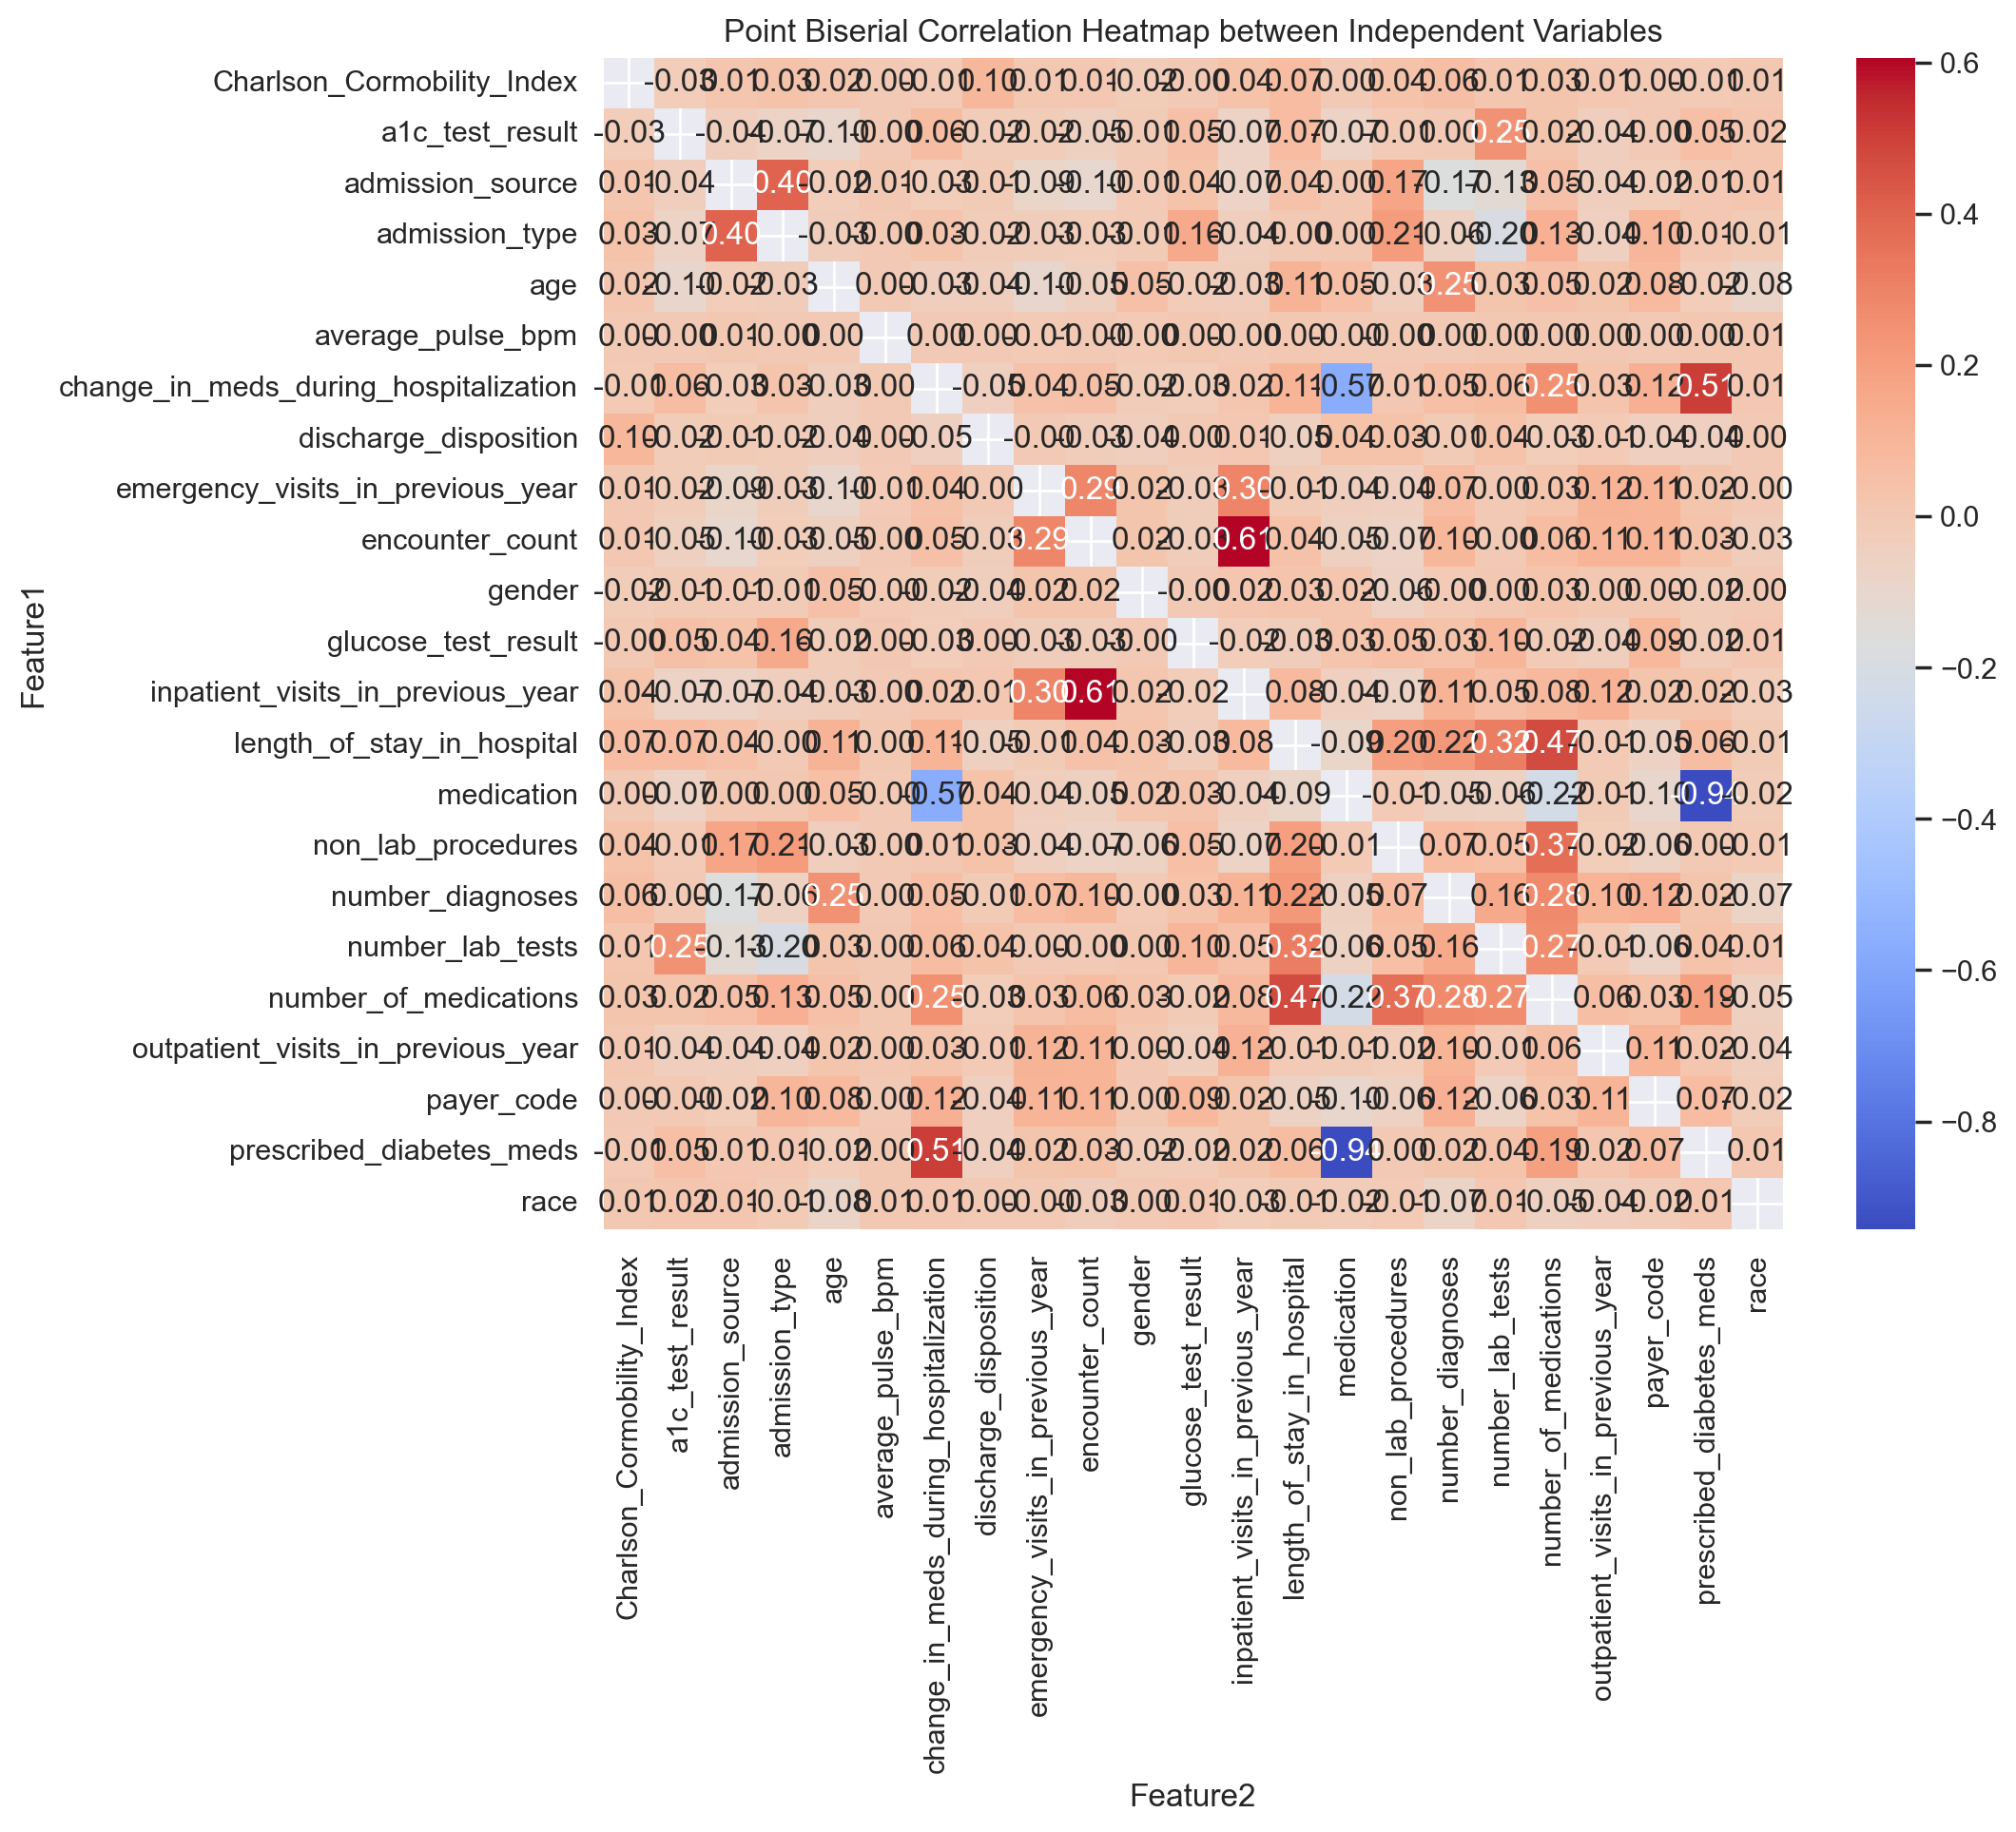

In [49]:
# Calculate point biserial correlation for each pair of features in X_train_over
point_biserial_corr = {}
for column1 in X_train_over.columns:
    for column2 in X_train_over.columns:
        if column1 != column2:
            corr = pointbiserialr(
                X_train_over[column1], X_train_over[column2]).correlation
            point_biserial_corr[(column1, column2)] = corr

# Create a DataFrame to store the correlations
corr_df = pd.DataFrame(list(point_biserial_corr.items()), columns=[
                       'Feature Pair', 'Point Biserial Correlation'])

# Unpack the tuple into separate columns for index and columns
corr_df[['Feature1', 'Feature2']] = pd.DataFrame(
    corr_df['Feature Pair'].tolist(), index=corr_df.index)

# Drop the original 'Feature Pair' column
corr_df = corr_df.drop('Feature Pair', axis=1)

# Reshape data to create a correlation matrix
corr_matrix = corr_df.pivot(
    index='Feature1', columns='Feature2', values='Point Biserial Correlation')

# Create a heatmap using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Point Biserial Correlation Heatmap between Independent Variables')

plt.savefig(os.path.join('..', 'figures', 'exp_analysis', 'Feature_Selection_Multiclass_Biserial.png'), dpi=200)

plt.show()

<a class="anchor" id="3.2-bullet">

#### 3.2 Lasso
    
</a>

In [50]:
def plot_importance(coef, name):
    imp_coef = coef.sort_values()
    plt.figure(figsize=(8, 10))
    imp_coef.plot(kind="barh")
    plt.title("Feature importance using " + name + " Model")

    plt.savefig(os.path.join('..', 'figures', 'exp_analysis',
            'Feature_Selection_Multiclass_Lasso.png'), dpi=200)
    
    plt.show()

In [51]:
reg = LassoCV()

In [52]:
reg.fit(X_train_over, y_train_over)

LassoCV()

In [53]:
coef = pd.Series(reg.coef_, index=X_train_over.columns)

In [54]:
lasso_sorted = coef.sort_values()

In [55]:
# plot_importance(coef, 'Lasso')

In [56]:
non_important_features = coef[abs(coef) < 0.0015].index.tolist()

In [57]:
print('features to drop: ', non_important_features)

features to drop:  ['gender', 'glucose_test_result', 'a1c_test_result']


<a class="anchor" id="3.3-bullet">

#### 3.3 K-Best: Mutual Info Classification
    
</a>

In [58]:
x_mic = X_train_over.copy()

In [61]:
# Initialize SelectKBest with the desired scoring function
np.random.seed(42)

# For example, here we use mutual information for feature selection
k_best = SelectKBest(score_func=mutual_info_classif,
                     k=15)  # Select top k features

# Fit SelectKBest to the data
X_new = k_best.fit_transform(x_mic, y_train_over)

# Get the indices of the selected features
selected_feature_indices = k_best.get_support(indices=True)

# Print the indices of selected features
print("Selected feature indices:", selected_feature_indices)

# Optionally, you can also see the scores of the features
print("Feature scores:", k_best.scores_)

Selected feature indices: [ 4  5  6  7  9 10 11 12 14 15 16 18 19 20 21]
Feature scores: [0.00115516 0.00069543 0.         0.         0.0067446  0.00957733
 0.03877489 0.00155339 0.         0.01412818 0.00803459 0.00237365
 0.00345358 0.00108827 0.00483131 0.00648825 0.00304666 0.
 0.006064   0.00854723 0.00177863 0.13800492 0.        ]


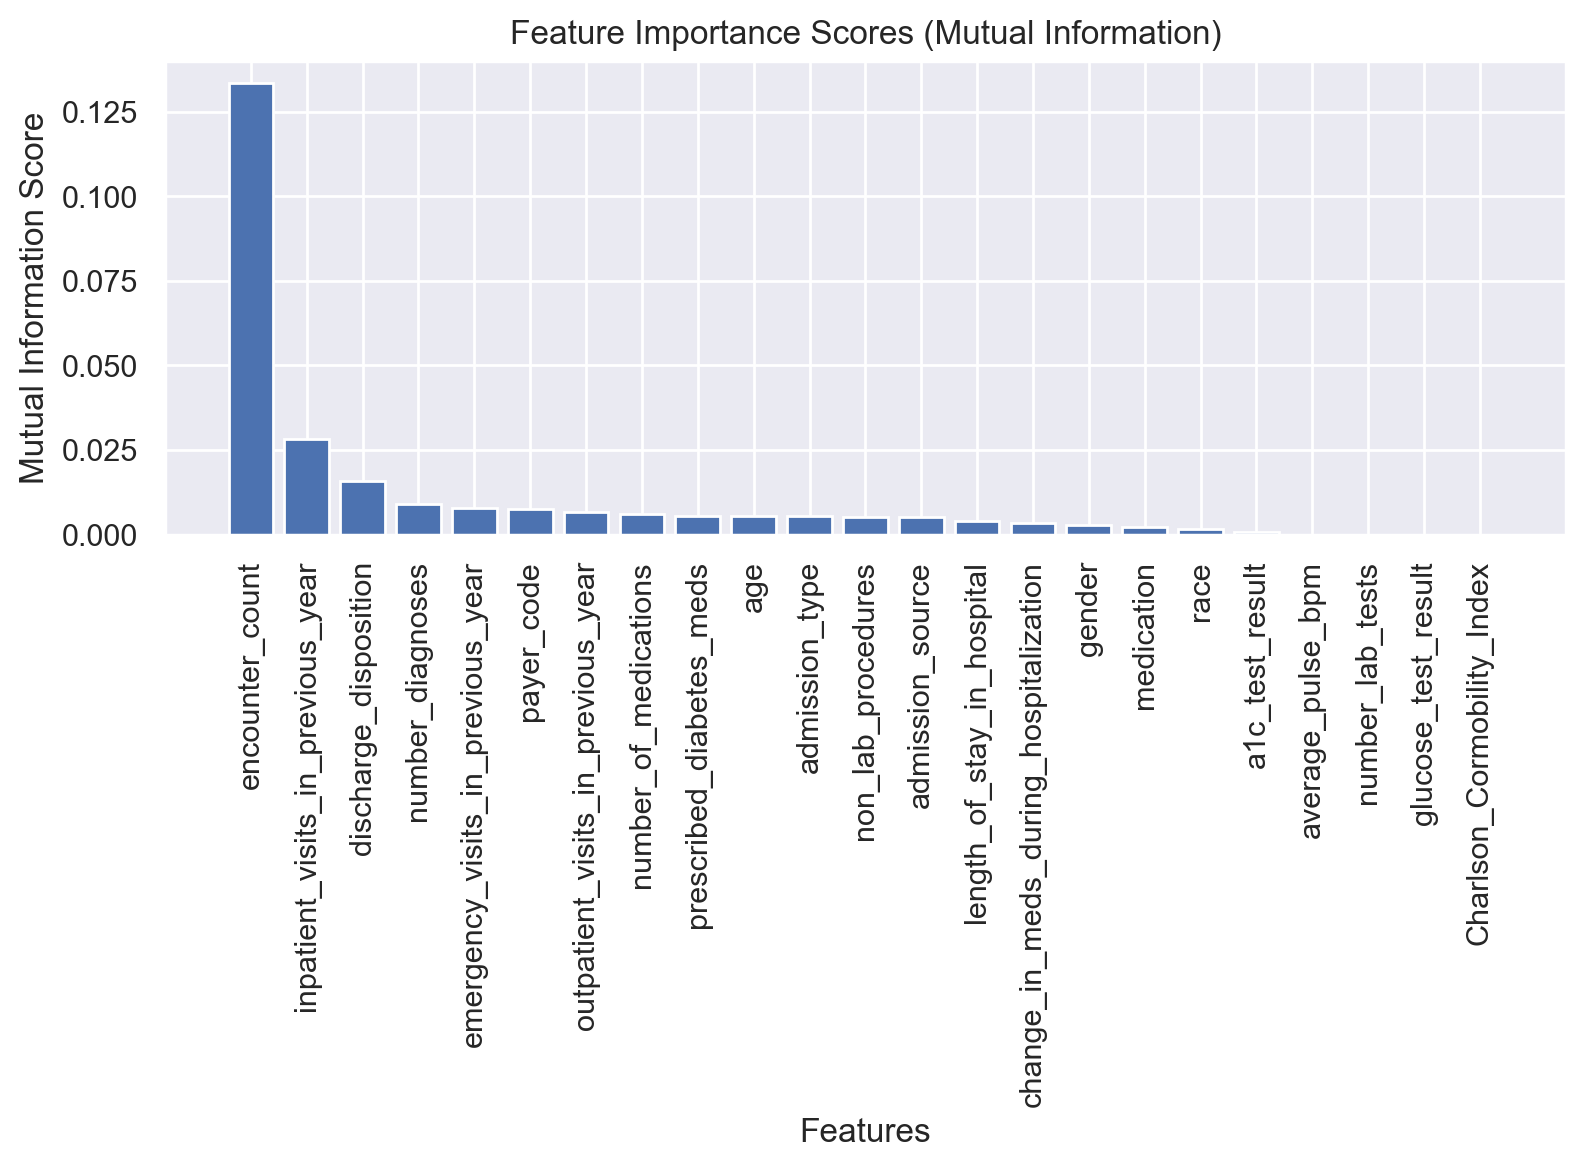

In [62]:
mic_scores = mutual_info_classif(x_mic, y_train_over)

# Sort feature importance scores and corresponding indices
indices = np.argsort(mic_scores)[::-1]
sorted_mic_scores = mic_scores[indices]
sorted_feature_names = x_mic.columns[indices]

# Create a bar plot to visualize feature importance scores
plt.figure(figsize=(8, 6))
bars = plt.bar(range(X.shape[1]), sorted_mic_scores,
               align='center', tick_label=sorted_feature_names)
plt.xticks(rotation='vertical')
plt.xlabel('Features')
plt.ylabel('Mutual Information Score')
plt.title('Feature Importance Scores (Mutual Information)')
plt.tight_layout()

plt.savefig(os.path.join('..', 'figures', 'exp_analysis',
            'Feature_Selection_Multiclass_MIC.png'), dpi=200)

plt.show()

The results from this test gave a very low score for the variables: 
- age, admission_type, non_lab_procedures, glucose_test_result, a1c_test_result, change_in_meds_during_hospitalization, prescribed_diabates_meds

<a class="anchor" id="3.4-bullet">

#### 3.4 ANOVA
    
</a>

In [60]:
X_anova = X_train_over.copy()

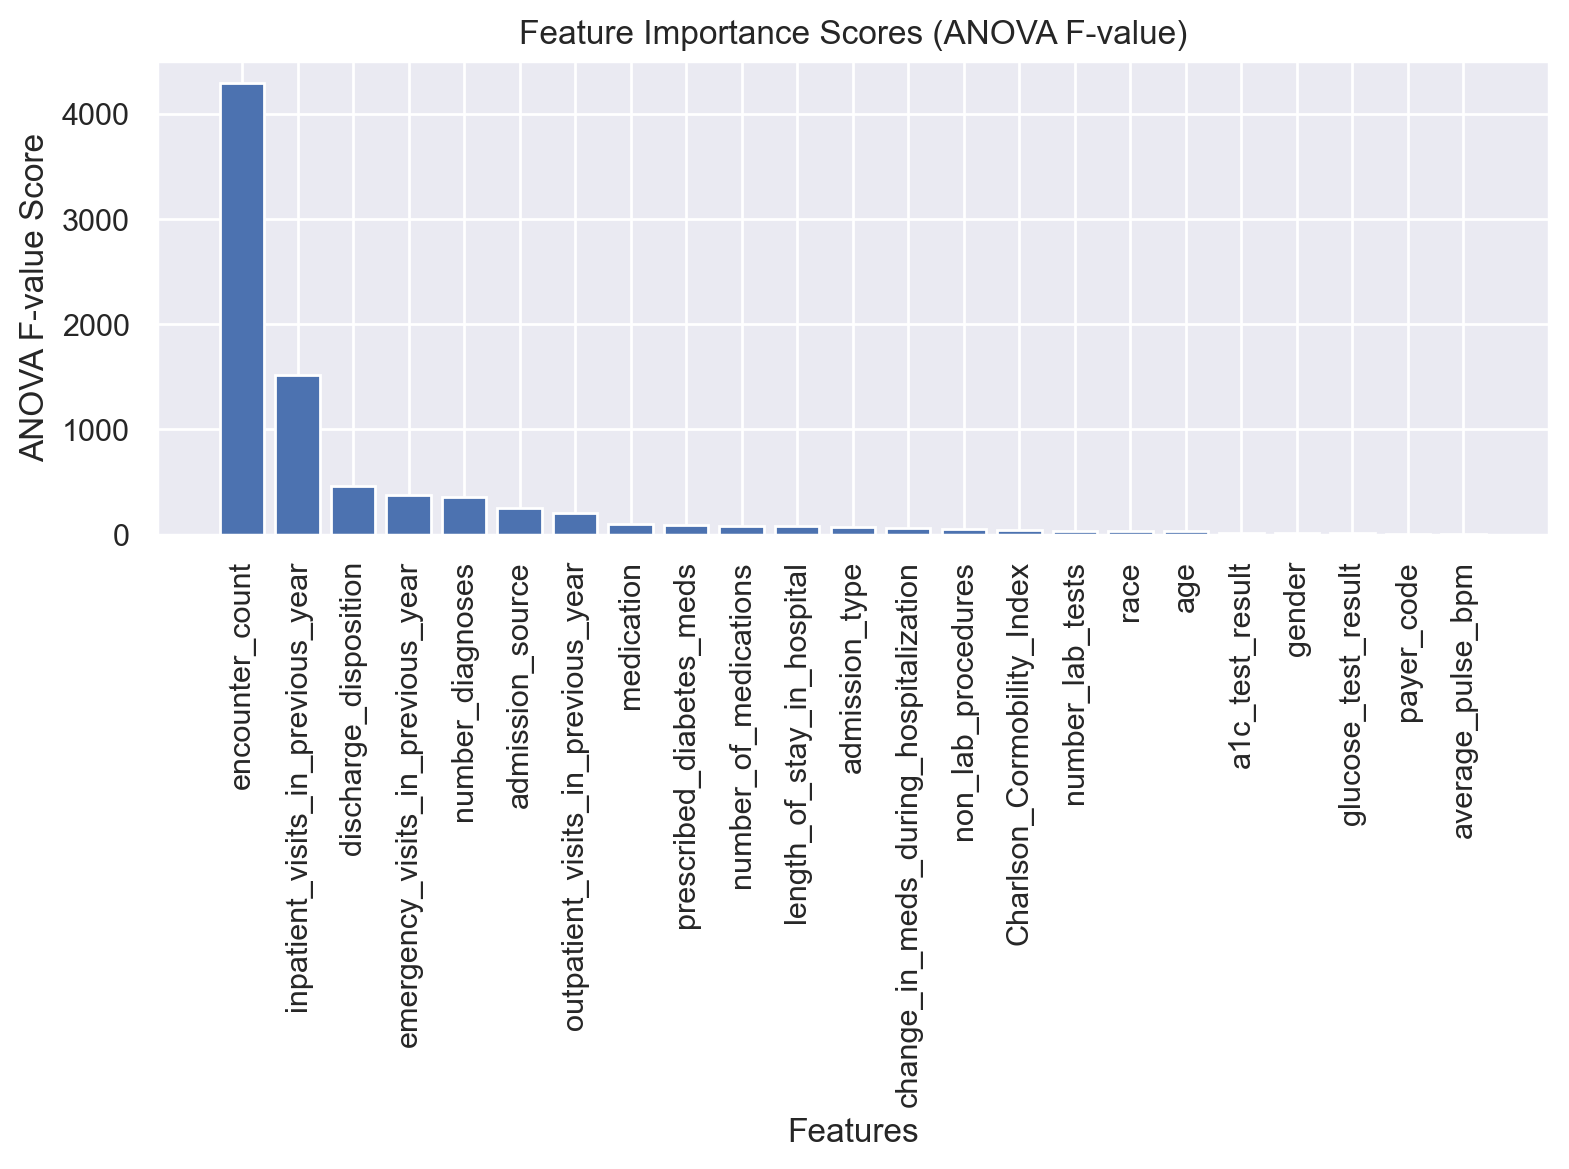

In [61]:
# Compute ANOVA F-value scores for each feature
f_scores, _ = f_classif(X_anova, y_train_over)

# Sort feature importance scores and corresponding indices
indices = np.argsort(f_scores)[::-1]
sorted_f_scores = f_scores[indices]
sorted_feature_names = X_anova.columns[indices]

# Create a bar plot to visualize feature importance scores
plt.figure(figsize=(8, 6))
bars = plt.bar(range(X.shape[1]), sorted_f_scores,
               align='center', tick_label=sorted_feature_names)
plt.xticks(rotation='vertical')
plt.xlabel('Features')
plt.ylabel('ANOVA F-value Score')
plt.title('Feature Importance Scores (ANOVA F-value)')
plt.tight_layout()

plt.savefig(os.path.join('..', 'figures', 'exp_analysis',
            'Feature_Selection_Multiclass_ANOVA.png'), dpi=200)
plt.show()


<a class="anchor" id="3.5-bullet">

#### 3.5 Random Forest
    
</a>

In [62]:
X_rf = X_train_over.copy()

In [63]:
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the Random Forest model to your data
random_forest.fit(X_rf, y_train_over)

# Get feature importances from the trained model
feature_importances = random_forest.feature_importances_

# Get column names from the feature DataFrame X_rf
column_names = X_rf.columns.tolist()

# Create a dictionary mapping feature importances to column names
importance_dict = {column_names[i]: feature_importances[i]
                   for i in range(len(column_names))}

# Sort feature importances by value in descending order
sorted_importance_dict = dict(
    sorted(importance_dict.items(), key=lambda item: item[1], reverse=True))

# Print feature importances with column names
print("Feature importances:")
for i, (feature_name, importance) in enumerate(sorted_importance_dict.items()):
    print(f"{i + 1}. Feature '{feature_name}': {importance}")

Feature importances:
1. Feature 'encounter_count': 0.1741135156276348
2. Feature 'average_pulse_bpm': 0.10661466639521208
3. Feature 'number_lab_tests': 0.10464665415629358
4. Feature 'number_of_medications': 0.08895672981324372
5. Feature 'length_of_stay_in_hospital': 0.06688826082054515
6. Feature 'age': 0.057515745105858634
7. Feature 'inpatient_visits_in_previous_year': 0.04738848996748043
8. Feature 'non_lab_procedures': 0.04404163342674926
9. Feature 'number_diagnoses': 0.04298184176771744
10. Feature 'discharge_disposition': 0.031030968827457806
11. Feature 'admission_type': 0.027735525520445982
12. Feature 'race': 0.027407020908708744
13. Feature 'admission_source': 0.023537586834837396
14. Feature 'gender': 0.021003683617357383
15. Feature 'outpatient_visits_in_previous_year': 0.02075005228837145
16. Feature 'medication': 0.019804530660259348
17. Feature 'Charlson_Cormobility_Index': 0.01850004810934603
18. Feature 'a1c_test_result': 0.017598869464897183
19. Feature 'change_in

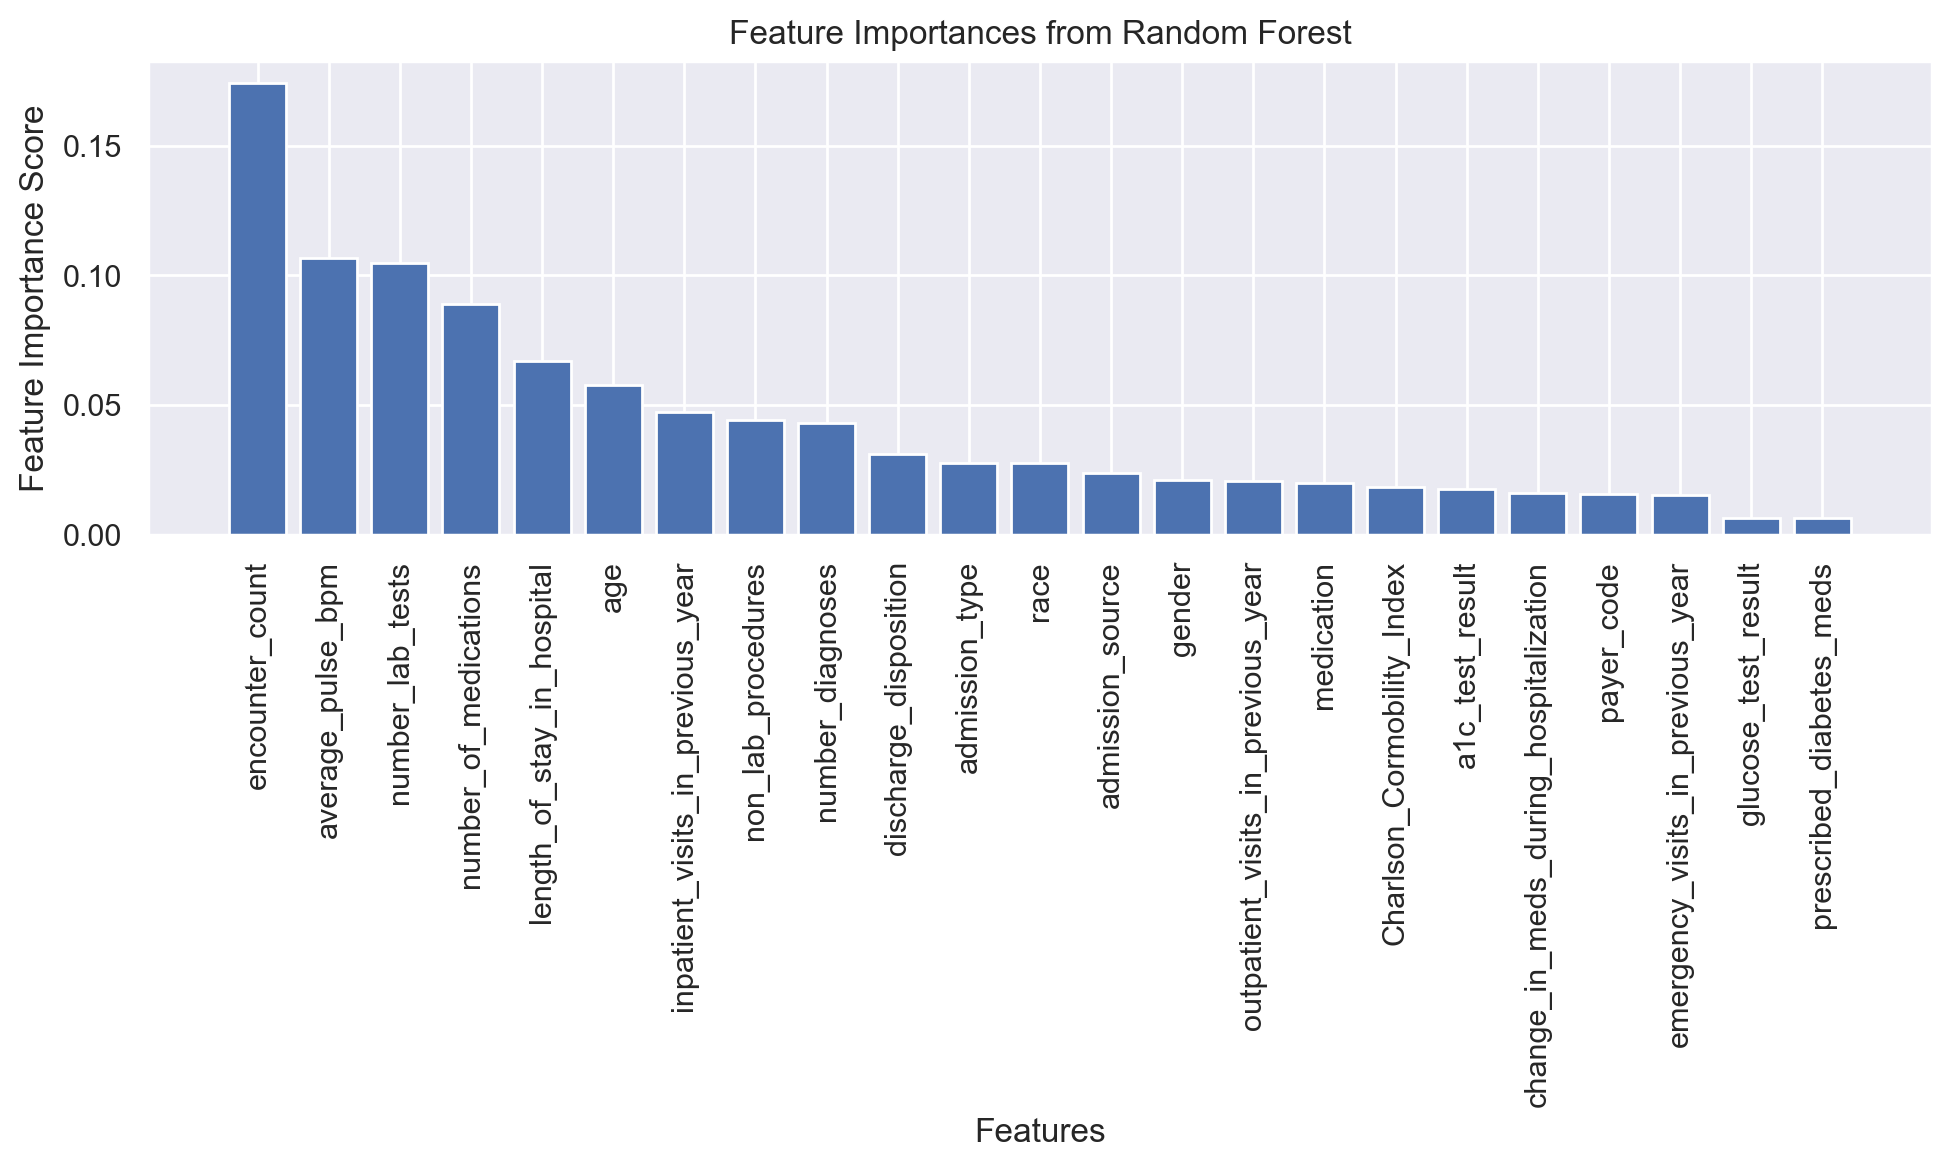

In [64]:
feature_names = list(sorted_importance_dict.keys())
importances = list(sorted_importance_dict.values())

# Create a bar plot to visualize feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances, align='center')
plt.xticks(range(len(importances)), feature_names, rotation='vertical')
plt.xlabel('Features')
plt.ylabel('Feature Importance Score')
plt.title('Feature Importances from Random Forest')
plt.tight_layout()

plt.savefig(os.path.join('..', 'figures', 'exp_analysis',
            'Feature_Selection_Multiclass_RF.png'), dpi=200)

plt.show()

<a class="anchor" id="3.6-bullet">

#### 3.6 Feature Selection Summary
    
</a>

In [65]:
feature_selection_tests = pd.read_excel(
    '../FeatureSelection.xlsx', sheet_name='MS')

feature_selection_tests

,Variable,Lasso,Point Biserial,Kbest - MIC,ANOVA,Random Forests,Nº True,%True,Decision
0,race,True,True,True,False,True,4,0.8,Keep
1,gender,False,True,True,False,True,3,0.6,Drop
2,age,True,True,False,False,True,3,0.6,Drop
3,payer_code,True,True,True,False,True,4,0.8,Keep
4,outpatient_visits_in_previous_year,True,True,True,True,True,5,1.0,Keep
5,emergency_visits_in_previous_year,True,True,True,True,True,5,1.0,Keep
6,inpatient_visits_in_previous_year,True,True,True,True,True,5,1.0,Keep
7,admission_type,True,True,False,True,True,4,0.8,Keep
8,average_pulse_bpm,True,True,True,False,True,4,0.8,Keep
9,discharge_disposition,True,True,True,True,True,5,1.0,Keep


In [66]:
columns_to_drop = ['gender', 'age', 'non_lab_procedures',
                   'glucose_test_result', 'a1c_test_result', 'prescribed_diabetes_meds']

In [67]:
X_train_selected = X_train_over.copy()
X_train_selected.drop(columns_to_drop, axis=1, inplace=True)

X_val_selected = X_val_df_knn.copy()
X_val_selected.drop(columns_to_drop, axis=1, inplace=True)

X_test_selected = X_test_df_ready.copy()
X_test_selected.drop(columns_to_drop, axis=1, inplace=True)


<a class="anchor" id="4-bullet">

### 4. Model application/selection
    
</a>

<a class="anchor" id="4.1-bullet">

#### 4.1 Function to run models
    
</a>

In [68]:
##### Function to run models

def scores(model):
    score_train = []
    score_val = []
    score_precision = []
    score_recall = []
    timer = []
    X_train = X_train_selected
    y_train = y_train_over
    X_val = X_val_selected
    y_val_selected = y_val
    
    # start counting time
    begin = time.perf_counter()
    # fit the model to the data
    model.fit(X_train, y_train)
    # finish counting time
    end = time.perf_counter()
    # check the f1_score weighted for the train dataset
    f1_weighted_train = f1_score(y_train, model.predict(X_train), average='weighted')
    # check the f1_score weighted for the valid dataset
    f1_weighted_valid = f1_score(y_val_selected, model.predict(X_val), average='weighted')
    # check the precision weighted for the valid dataset
    precision = precision_score(y_val, model.predict(X_val), average='weighted')
    # check the recall weighted for the valid dataset
    recall = recall_score(y_val, model.predict(X_val), average='weighted')
    
    
    # append the scores and time
    score_train.append(f1_weighted_train)
    score_val.append(f1_weighted_valid)
    score_precision.append(precision)
    score_recall.append(recall)
    timer.append(end-begin)
    model_time = round(np.mean(timer), 3)
    model_train = round(np.mean(score_train), 3)
    model_val = round(np.mean(score_val), 3)
    model_precision = round(np.mean(score_precision), 3)
    model_recall = round(np.mean(score_recall), 3)

    return model_time, model_train, model_val, model_precision, model_recall

def show_results(df, *args):
    """
    Receive an empty dataframe and the different models and call the function scores
    """
    count = 0
    # for each model passed as argument
    for arg in args:
        # obtain the results provided by scores
        model_time, model_train, model_val, model_precision, model_recall = scores(arg)
        # store the results in the right row
        df.iloc[count] = model_time, model_train, model_val, model_precision, model_recall
        count+=1
    return df

<a class="anchor" id="4.2-bullet">

#### 4.2 Models application
    
</a>

In [69]:
##### Logistic Regression -----------------------------------------------
log_model = LogisticRegression( )

##### Gaussian Naive Bayes ----------------------------------------------
modelNB = GaussianNB( )

##### Instance Based Learning (KNN) -------------------------------------
modelKNN = KNeighborsClassifier( )

##### Neural Networks ---------------------------------------------------
modelmlp = MLPClassifier(random_state = 0)

##### Decision Trees ----------------------------------------------------
modeldt = DecisionTreeClassifier(random_state = 0)

##### Random Forest -----------------------------------------------------
modelrf = RandomForestClassifier(random_state = 0)

##### Adaboost ----------------------------------------------------------
model_ab = AdaBoostClassifier(random_state = 0)

##### Gradient Boost ----------------------------------------------------
gradient_boost = GradientBoostingClassifier(random_state = 0)

In [70]:
df = pd.DataFrame(columns = ['Time','Train','Validation', 'Precision', 'Recall'], 
                  index = ['Logistic Regression', 'Gaussian Naive', 'KNN', 'Neural Network','Decision Tree', 'Random Forest', 'Adaboost', 'Gradient Boost'])
show_results(df, log_model, modelNB, modelKNN, modelmlp, modeldt, modelrf, model_ab, gradient_boost)

,Time,Train,Validation,Precision,Recall
Logistic Regression,0.413,0.605,0.604,0.627,0.653
Gaussian Naive,0.012,0.581,0.578,0.582,0.614
KNN,0.004,0.721,0.599,0.59,0.614
Neural Network,31.621,0.669,0.65,0.652,0.681
Decision Tree,0.485,1.0,0.555,0.558,0.552
Random Forest,12.235,1.0,0.644,0.648,0.679
Adaboost,1.008,0.637,0.636,0.64,0.671
Gradient Boost,11.037,0.651,0.643,0.661,0.685


<a class="anchor" id="4.3-bullet">

#### 4.3 Grid Search
    
</a>

 ##### Note: Since the GridSearchCV take a lot of time we let them commented out so that it is not executed.

In [71]:
# ##### Logistic Regression Grid Search

# param_grid_lg = {'penalty': ['l1', 'l2', 'elasticnet', 'none'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000], 'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

# grid = GridSearchCV(log_model, param_grid_lg, cv=10, scoring='f1_weighted')
# grid.fit(X_train_selected, y_train_over)

# print(grid.best_params_)

{'C': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}


In [ ]:
# ##### Neural Networks Grid Search
# param_grid_nn = {'hidden_layer_sizes': [(10,), (50,), (100,)], 'activation': ['tanh', 'relu', 'logistic'], 'solver': ['sgd', 'adam','lbfgs'],
#     'learning_rate': ['constant','adaptive','invscaling'], 'learning_rate_init': [0.001, 0.01, 0.5], 'max_iter': [20, 200, 1000]}

# grid = GridSearchCV(modelmlp, param_grid_nn, cv=10, scoring='f1_weighted')
# grid.fit(X_train_selected, y_train_over)

# print(grid.best_params_)

#### We were not able to optimally run the grid search for this model.

In [ ]:
# ##### Decision Trees Grid Search
# param_grid_dt = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'], 'max_depth': [None, 2, 10, 15, 20], 'max_leaf_nodes': [None, 10, 20, 50], 'min_samples_split': [10, 200, 500],
#     'min_samples_leaf': [100, 500], 'min_impurity_decrease': [0, 0.1, 0.2]}

# grid = GridSearchCV(modeldt, param_grid_dt, n_jobs=-1, cv=5, scoring='f1_weighted')
# grid.fit(X_train_selected, y_train_over)

# print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 10, 'max_leaf_nodes': None, 'min_impurity_decrease': 0, 'min_samples_leaf': 100, 'min_samples_split': 10, 'splitter': 'best'}


In [ ]:
# ##### Random Forest Grid Search
# param_grid_rf = {'bootstrap': [True, False], 'max_depth': [80, 90, 100, 150], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [2, 3, 4, 5], 'min_samples_split': [5, 10, 12],
#     'n_estimators': [5, 20, 50, 75, 100]}

# grid = GridSearchCV(estimator=modelrf, param_grid=param_grid_rf, scoring='f1_weighted', n_jobs=-1, cv=5)
# grid_result = grid.fit(X_train_selected, y_train_over)

# print(grid.best_params_)

{'bootstrap': False, 'max_depth': 150, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 20}


In [ ]:
# ##### Adaboost Grid Search
# param_grid_ad = {'n_estimators': [140, 160, 180, 200, 220, 240], 'learning_rate': [1, 1.2, 1.4, 1.6, 1.8, 2,]}

# grid = GridSearchCV(model_ab, param_grid_ad, scoring='f1_weighted', cv=5)
# grid.fit(X_train_selected, y_train_over)

# print(grid.best_params_)

{'learning_rate': 1.4, 'n_estimators': 180}


In [ ]:
##### Gradient Boost Grid Search
param_grid_gb = {'n_estimators': [50, 100, 150, 200], 'learning_rate': [0.01, 0.1, 0.2, 0.3]}

grid = GridSearchCV(gradient_boost, param_grid_gb, scoring='f1_weighted', cv=5)
grid.fit(X_train_selected, y_train_over)

print(grid.best_params_)

{'learning_rate': 0.2, 'n_estimators': 200}


<a class="anchor" id="4.4-bullet">

#### 4.4 Optimized Models
    
</a>

In [77]:
##### Logistic Regression -----------------------------------------------
log_model = LogisticRegression(C = 1000, penalty='l2', solver='lbfgs')

##### Gaussian Naive Bayes ----------------------------------------------
modelNB = GaussianNB( )

##### Instance Based Learning (KNN) -------------------------------------
modelKNN = KNeighborsClassifier( )

##### Neural Networks ---------------------------------------------------
modelmlp = MLPClassifier(random_state=0)

##### Decision Trees ----------------------------------------------------
modeldt = DecisionTreeClassifier(criterion = 'gini', max_depth = 10, max_leaf_nodes = None, min_impurity_decrease = 0, min_samples_leaf = 100, min_samples_split = 10, splitter = 'best', random_state = 0)

##### Random Forest -----------------------------------------------------
modelrf = RandomForestClassifier(bootstrap=True, max_depth=80, max_features='sqrt', min_samples_leaf=5, min_samples_split=12, n_estimators=50, random_state = 0)

##### Adaboost ----------------------------------------------------------
model_ab = AdaBoostClassifier(learning_rate=1.4, n_estimators=180, random_state = 0)

##### Gradient Boost ----------------------------------------------------
gradient_boost = GradientBoostingClassifier(learning_rate=0.2, n_estimators=200, max_depth=2, random_state = 0)

In [78]:
df = pd.DataFrame(columns = ['Time','Train','Validation', 'Precision', 'Recall'], 
                  index = ['Logistic Regression', 'Gaussian Naive', 'KNN', 'Neural Network','Decision Tree', 'Random Forest', 'Adaboost', 'Gradient Boost'])
show_results(df, log_model, modelNB, modelKNN, modelmlp, modeldt, modelrf, model_ab, gradient_boost)

,Time,Train,Validation,Precision,Recall
Logistic Regression,0.419,0.605,0.604,0.626,0.652
Gaussian Naive,0.011,0.581,0.578,0.582,0.614
KNN,0.004,0.721,0.599,0.59,0.614
Neural Network,30.749,0.669,0.65,0.652,0.681
Decision Tree,0.092,0.649,0.637,0.64,0.68
Random Forest,2.247,0.737,0.643,0.654,0.685
Adaboost,3.578,0.638,0.636,0.639,0.672
Gradient Boost,15.677,0.654,0.646,0.661,0.686


<a class="anchor" id="4.5-bullet">

#### 4.5 Stacking and Model Performances
    
</a>

In [114]:
estimators = [('nn', MLPClassifier(random_state = 0)),
              ('gb', GradientBoostingClassifier(learning_rate=0.2, n_estimators=200, max_depth=2, random_state = 0))]

In [115]:
st = StackingClassifier(estimators = estimators, final_estimator = LogisticRegression()).fit(X_train_selected, y_train_over)

In [116]:
df = pd.DataFrame(columns = ['Time','Train','Validation', 'Precision', 'Recall'], 
                  index = ['Logistic Regression', 'Gaussian Naive', 'KNN', 'Neural Network','Decision Tree', 'Random Forest', 'Adaboost', 'Gradient Boost', 'Stacking'])
show_results(df, log_model, modelNB, modelKNN, modelmlp, modeldt, modelrf, model_ab, gradient_boost, st)

,Time,Train,Validation,Precision,Recall
Logistic Regression,0.396,0.605,0.604,0.626,0.652
Gaussian Naive,0.011,0.581,0.578,0.582,0.614
KNN,0.004,0.721,0.599,0.59,0.614
Neural Network,17.488,0.669,0.65,0.652,0.681
Decision Tree,0.09,0.649,0.637,0.64,0.68
Random Forest,2.23,0.737,0.643,0.654,0.685
Adaboost,3.514,0.638,0.636,0.639,0.672
Gradient Boost,15.289,0.654,0.646,0.661,0.686
Stacking,179.016,0.66,0.649,0.658,0.685


<a class="anchor" id="5-bullet">

### 5 Export result
    
</a>

In [69]:
df_test_to_predict_gb = X_test_selected.copy()

# Choosing the best model

modelgb = GradientBoostingClassifier(learning_rate=0.2, n_estimators=200, max_depth=2, random_state = 0)

modelgb.fit(X_train_selected, y_train_over)

y_pred_test_gb = modelgb.predict(df_test_to_predict_gb)

df_test_to_predict_gb['readmitted_multiclass_bool'] = y_pred_test_gb

# Changing the values into str:
conversion_multiclass_change = {0: '<30 days', 1: '>30 days', 2: 'No'}
df_test_to_predict_gb['readmitted_multiclass'] = df_test_to_predict_gb['readmitted_multiclass_bool'].map(
    conversion_multiclass_change)

# Select the column to export
df_prediction_lmlp = df_test_to_predict_gb[['readmitted_multiclass']]

# Export into a .csv
df_prediction_lmlp.to_csv(os.path.join('..', 'exported_predictions', 'multiclass_prediction_group_07.csv'))